## STA 5737 Assignment 4 Hope Mullins

In [1]:
import os
os.chdir('C:/ucf_classes/sta_5735')

### Question 1

The data for this question may be found at: https://www.kaggle.com/datasets/adilshamim8/math-students 

Begin by loading in the necessary packages.

In [2]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### 1) Load the data and prepare it for analysis with PCA:

In [3]:
math = pd.read_csv("Math-Students.csv")

For PCA, we are only able to use numerical values; therefore, we will need to drop all categorical values, unless there is a clear order to their values (in which case, we could use one-hot encoding to convert these strings to numeric). Let's begin by exploring the variables in our dataset.

In [4]:
math.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      399 non-null    object
 1   sex         399 non-null    object
 2   age         399 non-null    int64 
 3   address     399 non-null    object
 4   famsize     399 non-null    object
 5   Pstatus     399 non-null    object
 6   Medu        399 non-null    int64 
 7   Fedu        399 non-null    int64 
 8   Mjob        399 non-null    object
 9   Fjob        399 non-null    object
 10  reason      399 non-null    object
 11  guardian    399 non-null    object
 12  traveltime  399 non-null    int64 
 13  studytime   399 non-null    int64 
 14  failures    399 non-null    int64 
 15  schoolsup   399 non-null    object
 16  famsup      399 non-null    object
 17  paid        399 non-null    object
 18  activities  399 non-null    object
 19  nursery     399 non-null    object
 20  higher    

Using the info() method, we can see the number of observations, the variables we are dealing with, the type of each variable, and the number of null observations. Looking specifically at this DataFrame, we know we are dealing with 399 rows and no null values within any column, so this is a fairly small, clean dataset. Of the thirty-three variables, sixteen variables are already in numerical form while seventeen are strings. Next, it would be smart to observe whether or not any of these categorical variables have an order. The head() method allows us to see the first few rows, so we should use this to observe if any of the columns should be converted into numeric values.

In [5]:
math.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


Looking through the first ten observations, the only variable I would encode is 'famsize', which contains the values 'LT3' (specifying that the family size is less than three) and 'GT3' (specifying that the family size is greater than three). There is clearly an order to this (small vs. large family), so I'll encode this variable. 

In [6]:
math['famsize'] = math['famsize'].map({'LE3': 0, 'GT3': 1})

Since none of the other categorical variables are relevant for Principal Component Analysis, we may simply drop them from our DataFrame.

In [7]:
math_num = math.select_dtypes(include = [np.number])

In [8]:
math_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         399 non-null    int64
 1   famsize     399 non-null    int64
 2   Medu        399 non-null    int64
 3   Fedu        399 non-null    int64
 4   traveltime  399 non-null    int64
 5   studytime   399 non-null    int64
 6   failures    399 non-null    int64
 7   famrel      399 non-null    int64
 8   freetime    399 non-null    int64
 9   goout       399 non-null    int64
 10  Dalc        399 non-null    int64
 11  Walc        399 non-null    int64
 12  health      399 non-null    int64
 13  absences    399 non-null    int64
 14  G1          399 non-null    int64
 15  G2          399 non-null    int64
 16  G3          399 non-null    int64
dtypes: int64(17)
memory usage: 53.1 KB


Therefore, we are left with all numerical columns, just as it should be for PCA. The variables kept are 'age' (age of the student), 'famsize' (size of family), 'Medu' (mother's education. This is ranked from 0 [no education] to 5 [higher education]), 'Fedu' (father's education, following the same scale as 'Medu'), 'traveltime' (home to school travel time, ranging from one to four hours), 'studytime' (weekly study time, ranging from one to ten hours), 'failures' (number of past class failures, ranging from zero to three), 'famrel' (quality of family relationships. This is ranked from 1 [very bad] to 5 [excellent]), 'freetime' (free time after school. This is ranked from 1 [very low] to 5 [very high]), 'goout' (how often a student goes out with friends. This is ranked from 1 [very low] to 5 [very high]), 'Dalc' (alcohol consumption during the workday, ranked from 1 [very low] to 5 [very high]), 'Walc' (alcohol consumption during the weekend, following the same scale as 'Dalc'), 'health' (current health status, ranked from 1 [very bad] to 5 [very good]), 'absences' (number of times the student missed school, ranging from zero to ninety-three), 'G1' (first period grade in math, ranging from zero to twenty), 'G2' (second period grade in math, with the same values as 'G1'), and 'G3' (the student's final grade in math, with the same values as 'G1' and 'G2').

Now, with only numeric values, we need to standardize our data. In Principal Component Analysis, our first/best principal component/eigenvector is a vector that is the most polarizing, representative of the biggest aspects of change (the largest variance). Without standardizing our data, we do not take into account how variables may be scaled differently. If some variables have very large ranges and others have small ranges, then PCA - in an attempt to maximize the variance - will have the variables with the largest range dominate. Standardizing our variables allows each one to contribute equally to our analysis.

In [9]:
scaler = StandardScaler()
Vars = scaler.fit_transform(math_num)

With this, our data is fully prepared for analysis with PCA.

### 2) Find the Eigenvalues and Eigenvectors. Plot the sorted eigen values (lowest rank and value).

Our ultimate goal in Principal Component Analysis is to reduce the dimensionality of our dataset while still retaining as much of the variance as possible. This differs from variable reduction, as all of our variables and data are still utilized in the PCA process. Regarding this dataset on math students, our best eigenvector essentially represents a hypothetical student that creates the largest variance (when multiplying this eigenvector by the student data, we obtain the highest and lowest possible values). Additionally, we could think of eigenvectors as vectors that define the direction of the principal components. Eigenvalues, on the other hand, quantify how much data is explained by each principal component; it is essentially a scale, telling us how much of the variance is in that direction. A higher eigenvalue means that the corresponding component captured more of the variance in the data.

Every eigenvector has an eigenvalue associated with it. Their number is equivalent to the number of dimensions in the data. For our dataset, we have seventeen numerical variables, so there are seventeen eigenvectors and seventeen eigenvalues. 

Before calculating our eigenvectors/eigenvalues, we should calculate a covariance matrix (which will be 17 x 17). This is calculated from the standardized dataset, demonstrating the relationship between variables. Features that are highly correlated often contain redundant (unnecessary) information. Contained within the covariance matrix, along the diagonal, are the variances of each of our variables.

To generate the covariance matrix, we may use the numpy function cov(). Because this function expects our features to be represented on the rows and the observations to be represented on the columns, we also must transpose our variables.

In [10]:
cov_matrix = np.cov(Vars.T)

With another numpy method linalg.eig(), we can calculate the eigenvalues and eigenvectors, as well as plot the sorted eigenvalues:

In [11]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues

array([3.38015836, 2.12581945, 1.62853221, 0.07978361, 0.18319378,
       0.2991363 , 0.35973416, 1.28043547, 1.17169561, 0.61730774,
       0.63828538, 0.72829017, 0.77326815, 1.0158054 , 0.87838863,
       0.92792646, 0.95495268])

In [12]:
sort_indices = np.argsort(eigenvalues)[::-1]
sort_eigenvalues = eigenvalues[sort_indices]
sort_eigenvectors = eigenvectors[:, sort_indices]

sort_eigenvalues

array([3.38015836, 2.12581945, 1.62853221, 1.28043547, 1.17169561,
       1.0158054 , 0.95495268, 0.92792646, 0.87838863, 0.77326815,
       0.72829017, 0.63828538, 0.61730774, 0.35973416, 0.2991363 ,
       0.18319378, 0.07978361])

Each number in this array represents an amount of the variance explained by our seventeen Principal Components. To better understand this, let's calculate the total variance.

In [13]:
total_variance = np.sum(sort_eigenvalues)
total_variance

17.0427135678392

Therefore, the total variance in our standardized dataset concerning math students is approximately 17.0427. So, we see that Principal Component 1 explains 3.38015836 of the total variance in our dataset, while Principal Component 2 explains 2.12581945 of the total variance (and so on). Principal Component 17 explains the least amount of total variance at a value of just 0.07978361.

Plotting the sorted eigenvalues:

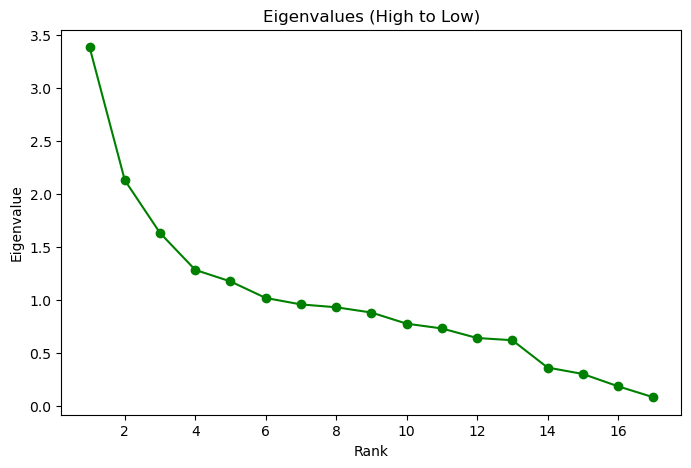

In [14]:
plt.figure(figsize = (8, 5))
plt.plot(np.arange(1, len(sort_eigenvalues)+1), sort_eigenvalues, 'go-')
plt.title('Eigenvalues (High to Low)')
plt.xlabel('Rank')
plt.ylabel('Eigenvalue')
plt.show()

From this plot, we can see a steep incline initially in the eigenvalues, but once we hit Principal Component 4, the difference in value becomes less drastic (though note a steeper drop from Principal Component 13 to 14, relative to previous and later points).

### 3) Plot the cumulative sum for the eigen values. Then find the number of largest eigen values needed to get 80% of the total sum.

To calculate the cumulative sum, we may use the numpy function cumsum() on our eigenvalues. Additionally, we can calculate the proportion of each cumulative sum value to the total variance.

In [15]:
cum_sum = np.cumsum(sort_eigenvalues)
cum_sum

array([ 3.38015836,  5.50597781,  7.13451002,  8.41494549,  9.5866411 ,
       10.60244651, 11.55739919, 12.48532565, 13.36371428, 14.13698243,
       14.86527259, 15.50355797, 16.12086571, 16.48059988, 16.77973617,
       16.96292996, 17.04271357])

In [16]:
cum_ratio = cum_sum / total_variance
cum_ratio

array([0.19833452, 0.32306932, 0.41862524, 0.4937562 , 0.56250673,
       0.62211023, 0.67814313, 0.73259024, 0.78413066, 0.82950302,
       0.87223625, 0.90968835, 0.94590956, 0.96701736, 0.98456951,
       0.99531861, 1.        ])

With this, we may now produce a plot of the cumulative sum:

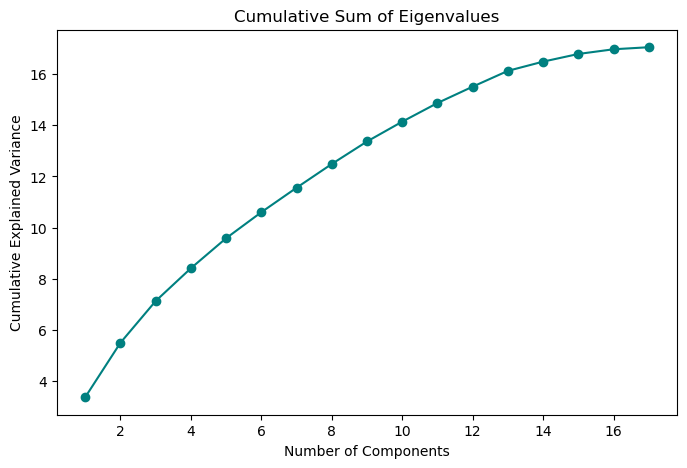

In [17]:
plt.figure(figsize = (8, 5))
plt.plot(np.arange(1, len(cum_sum) + 1), cum_sum, marker = 'o', color = 'teal')
plt.title('Cumulative Sum of Eigenvalues')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

As expected, we see a curve that is increasing at a decreasing rate. The Principal Components with the highest eigenvalues are located to the left of the x-axis, explaining more variance, while those with lower influence are located toward the right. We might also view this data from the proportional lens, where the y-axis measures the proportion of the variance that is explained as more Principal Components are introduced. Additionally, because we are asked to find the number of largest eigenvalues needed to caputure at least 80% of the total variance, we may visualize this by adding a horizontal line where y is equal to .8.

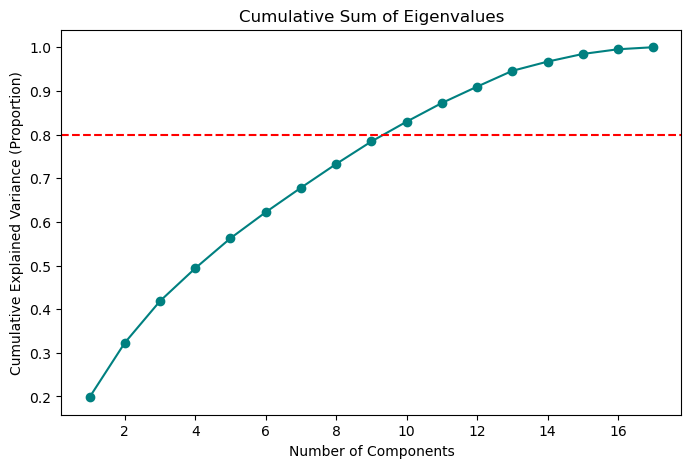

In [18]:
plt.figure(figsize = (8, 5))
plt.plot(np.arange(1, len(cum_ratio) + 1), cum_ratio, marker = 'o', color = 'teal')
plt.axhline(y = 0.8, color = 'r', linestyle = '--')
plt.title('Cumulative Sum of Eigenvalues')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (Proportion)')
plt.show()

The horizontal line falls slightly above the point where Principal Component 9 is represented. Therefore, we need the first ten eigenvalues to get 80% of the total sum. This can be confirmed by the following code. 'cum_ratio >= 0.8' returns an array of 'True' or 'False' values, 'True' being returned if the value in 'cum_ratio' is greater than or equal to 0.8. The numpy function argmax() returns the index of the first 'True' value. Because indexing begins at 0 in Python, we add 1 to this value to get the actual eigenvalue.

In [19]:
num_80 = np.argmax(cum_ratio >= 0.8) + 1
print(f"Number of components to reach 80% variance: {num_80}")

Number of components to reach 80% variance: 10


As seen numerically, in order to get 80% of the total variance, we need the first ten eigenvalues.

### 4) Project the data onto the largest Eigenvector and plot the projection. Then make comments.

"Projecting the data" simply means we will multiply the data by the largest eigenvector. Given that we had 399 rows in our dataset and 17 columns (399 x 17) and our largest eigenvector is 17 rows (17 x 1), we will end up with one value for each of the 399 rows in our student dataset. We shall simply utilize the PCA() function, first specifying the number of components we want to keep (in this case, just one), then fitting the PCA object to our data while transforming the data using fit_transform(). 

In [20]:
pca = PCA(n_components = 1)
Vars_1D = pca.fit_transform(Vars)

To plot the projection, we will just generate a histogram:

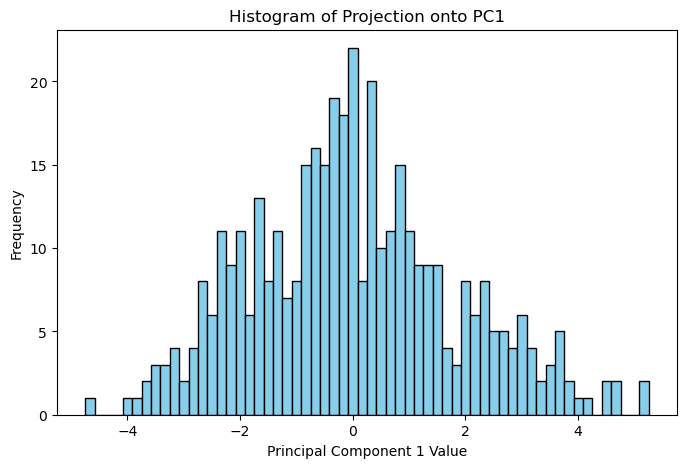

In [21]:
plt.figure(figsize = (8, 5))
plt.hist(Vars_1D, bins = 60, color = 'skyblue', edgecolor = 'black')
plt.title('Histogram of Projection onto PC1')
plt.xlabel('Principal Component 1 Value')
plt.ylabel('Frequency')
plt.show()

This histogram provides a visual representation of how the data is distributed along the direction of maximum variance. The data is centered around zero (naturally, because PCA centers the data by subtracting the mean from each feature), telling us that the average math student's characteristics are found in the center of this distribution. The range is close to 9, as it appears that the smallest value is close to -5, while the largest value is a bit larger than 5. The wider the spread, the larger the variance; since this is our first Principal Component, this is the largest range we will observe. But we see that students differ in their PC1 characteristics, as some score much lower while others score much higher. On the left, there is a slightly longer tail, indicating that a couple students veer away from the norm in one direction. 

### 5) Project the data onto the 2 largest eigenvectors and plot the projection on a scatter plot. Then make comments.

For this, we will follow a similar process as before, except the number of components in our PCA() function will be equal to 2.

In [22]:
pca_2 = PCA(n_components = 2)
Vars_2D = pca_2.fit_transform(Vars)

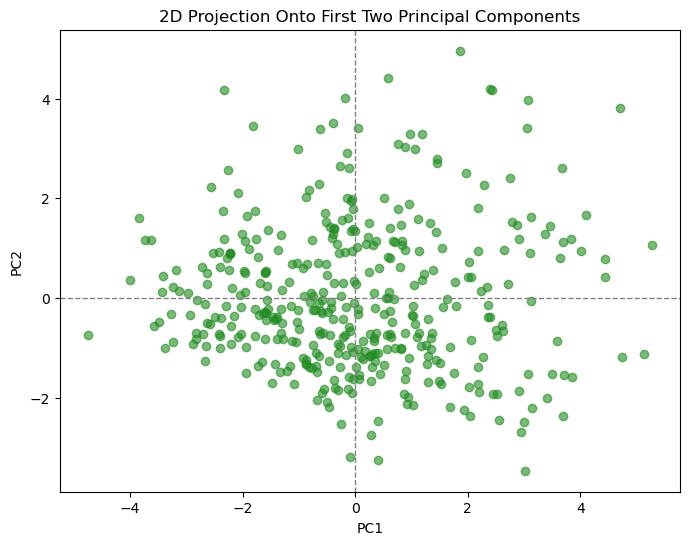

In [23]:
plt.figure(figsize = (8, 6))
plt.scatter(Vars_2D[:, 0], Vars_2D[:, 1], c = 'forestgreen', alpha = 0.6)
plt.title('2D Projection Onto First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
plt.show()

With this, the data all appear to be scattered throughout the majority of the plot. However, less data points fall as closely to the bottom left of the plot (where both PC1 and PC2 are very negative) and the top left of the plot (where PC1 is very negative and PC2 is very positive). Naturally the x-axis spans a wider range, because as mentioned previously, this represents the direction of most variance. Much of the data is centered around (0,0), and there is no strong, obvious directional structure at the moment. Attempting to cluster may assist with grouping our data.

### 6) On the previous result with 2 eigenvectors, is clustering applicable? If so how many clusters would be applied? Plot the sum of squares error for cluster numbers 1 to 10 and comment.

To check if our data can be clustered with the two largest eigenvectors, we might use K-means Clustering. This is the most common form of clustering, a process which groups data points into a specified number of clusters where each point belongs to a cluster with the closest mean. This partitioning of the data minimizes the variance within each cluster. 

Here, for each cluster from Cluster 1 to Cluster 10, we will calculate the sum of squared errors. The 'kmeans.inertia_' part measures the total distance between each point and its cluster center; the lower the inertia, the more compact the clusters.

In [24]:
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(Vars_2D)
    sse.append(kmeans.inertia_)

c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environme

With this, we may now plot the results. This is referred to as an "Elbow Plot". On the x-axis is the number of clusters, while the y-axis specifies the error. Additionally, we can pair the elbow plot results with a silhouette score. The Silhouette Score ranges from -1 to 1, with higher values indicating better clustering, negative values indicating points being assigned to the wrong cluster, and a value of 0 indicating a point is on or close to the decision boundary between two clusters.

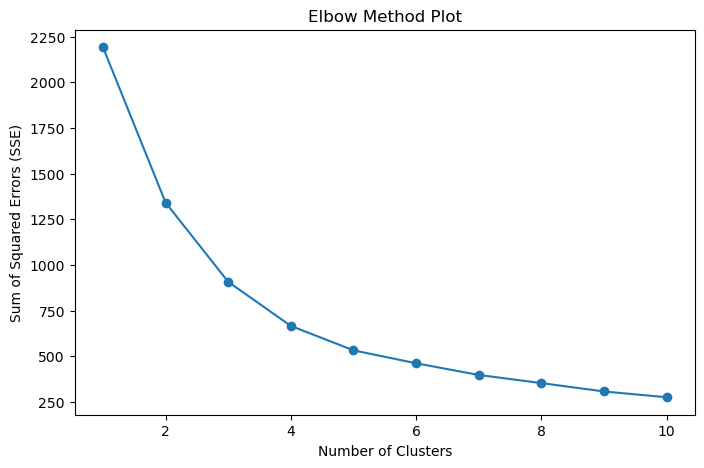

In [25]:
plt.figure(figsize = (8, 5))
plt.plot(range(1, 11), sse, marker = 'o')
plt.title('Elbow Method Plot')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.show()

The goal of the elbow plot is to look for the "bend" in the curve, where the error begins to level off. Based on this plot, I would argue that is around k = 4 (where the number of clusters is equal to four). Let's now obtain silhouette scores as well. They requires 2 clusters, so we must start the following for loop at 2 instead of 1. 

In [26]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(Vars_2D)
    silhouette_avg = silhouette_score(Vars_2D, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environme

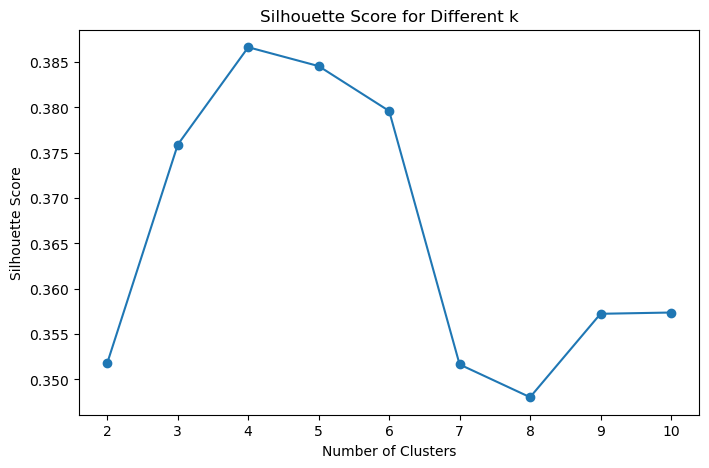

In [27]:
plt.figure(figsize = (8, 5))
plt.plot(range(2, 11), silhouette_scores, marker = 'o')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

Observing this plot, the highest silhouette score we attained was a little over 0.385, which is not a very large number on the scale (since we would like the number to be as close to one as possible). However, with these two eigenvectors, the optimal number of clusters is four. Since the silhouette score is not significantly high, the clustering procedure here may not perform very acurately. 

### 7) Using the number of components found for 80% of the total eigenvalues, find a suitable number of clusters.

We found previously that the number of components needed to cover 80% of the total variance was equal to ten. Therefore, we will run our PCA() function using ten components, and then rerun the elbow method and silhouette score processes to see if we obtain a new optimal number of clusters. However, we could also try clustering this ten-dimensional data with the optimal number of clusters equal to four, as we previously found, and compare the differences.

In [28]:
pca_10 = PCA(n_components = 10)
Vars_10D = pca_10.fit_transform(Vars)

In [29]:
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(Vars_10D)
    sse.append(kmeans.inertia_)

c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environme

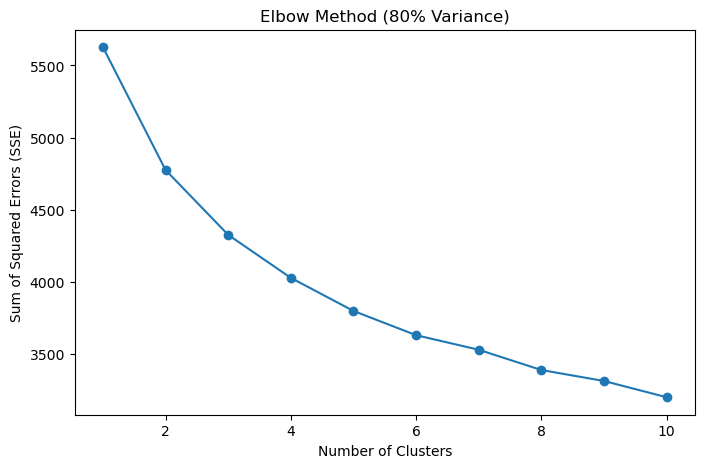

In [30]:
plt.figure(figsize = (8, 5))
plt.plot(range(1, 11), sse, marker = 'o')
plt.title('Elbow Method (80% Variance)')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.show()

From this, we see that the sum of squared errors increased from the previous amount, which makes complete sense as we have added more components that explain more of the variance. Testing the silhouette score again:

In [31]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(Vars_10D)
    silhouette_avg = silhouette_score(Vars_10D, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environme

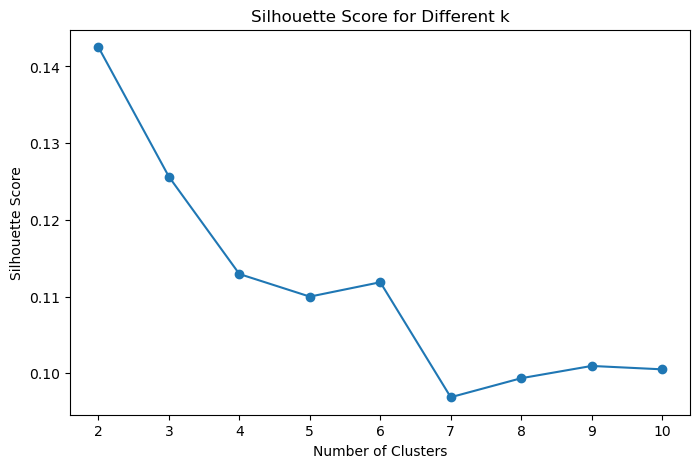

In [32]:
plt.figure(figsize = (8, 5))
plt.plot(range(2, 11), silhouette_scores, marker = 'o')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

Here, we obtain a lower silhouette score of just over 0.14, and the optimal number of clusters is now equal to two. Plotting these two clusters:

c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


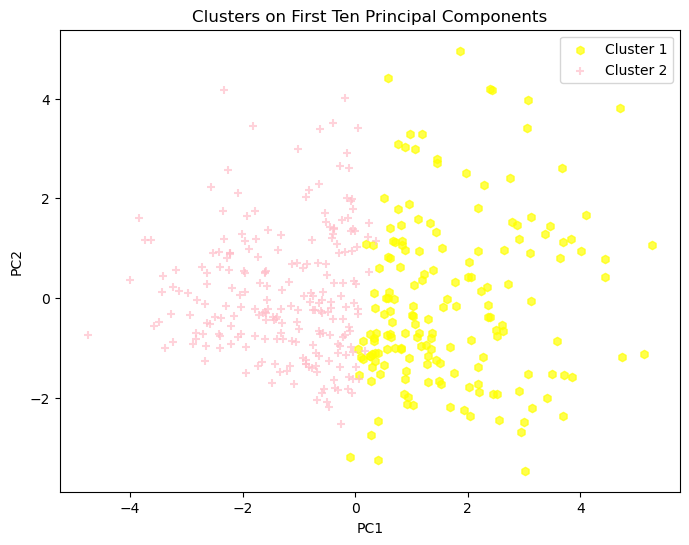

In [33]:
optimal_k = 2
kmeans = KMeans(n_clusters = optimal_k, random_state = 42)
labels = kmeans.fit_predict(Vars_10D)

markers = ['h', '+']
colors = ['yellow', 'pink']

plt.figure(figsize = (8, 6))
for cluster in range(optimal_k):
    cluster_points = Vars_10D[labels == cluster]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        marker = markers[cluster],
        color = colors[cluster],
        label = f'Cluster {cluster + 1}',
        alpha = 0.7)
plt.title(f'Clusters on First Ten Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

From this plot, we see a split right where PC1 is equal to 0. There is a tiny bit of overlap at this point, so this clustering process did not result in the most distinct clusters, but we are still able to visually interpret where the two groups split off. With this, we observe no clustering given the second Principal Component.

Again, let's repeat this process with the optimal number of clusters we previously found, k = 4:

c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\hem10\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


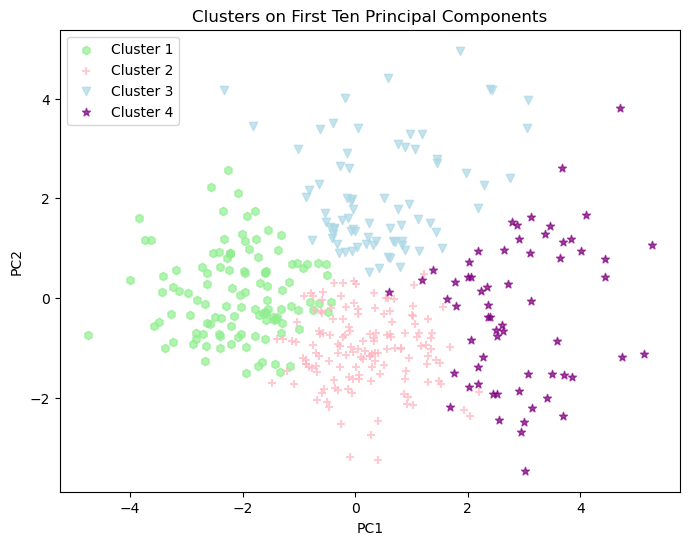

In [34]:
optimal_k = 4
kmeans = KMeans(n_clusters = optimal_k, random_state = 42)
labels = kmeans.fit_predict(Vars_10D)

markers = ['h', '+', 'v', '*']
colors = ['lightgreen', 'lightpink', 'lightblue', 'purple']

plt.figure(figsize = (8, 6))
for cluster in range(optimal_k):
    cluster_points = Vars_10D[labels == cluster]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        marker = markers[cluster],
        color = colors[cluster],
        label = f'Cluster {cluster + 1}',
        alpha = 0.7)
plt.title(f'Clusters on First Ten Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

From this plot, we now don't really see a split directly at PC1 = 0. Though there is also overlap here, we can see the general area where each cluster is separated. Cluster 4 does not appear to have been affected by PC2, as it is pretty evenly distributed acorss the PC2 axis. However, it lies entirely on the right side of the plot, where PC1 > 0 (the first noticeable point from left to right in Cluster 4 is around where PC1 is slightly below 1). Cluster 1 is the exactly opposite: On the PC1 axis, it lies entirely on the left side of the plot, where PC1 < 0. Additionally, this cluster is more compact than Cluster 4. It doesn't span almost the entire PC2 axis as Cluster 4 does, but rather it ranges from approximately -2 to 3.

On the other hand, Clusters 2 and 3 look like they have both been partitioned by the PC2 axis. Cluster 2, similar to Cluster 1, is more compact, but this time along the PC1 axis (it's range on the PC1 axis is roughly from -2 to 2). On the PC2 axis, the data points within this cluster all fall below the value of 1. Alternatively, all the data points in Cluster 3 fall above the value of 1 on the PC2 axis. On the PC1 axis, Cluster 3 appears to be more widely dispersed, but not by a much greater amount. 

Therefore, whether we use k = 2 or k = 4, there is a small amount of overlapping with our clusters. Regardless, it isn't too difficult to distinguish the approximate area where the clusters become separated from one another.

### Question 2

The data for this question may be found at: https://www.kaggle.com/datasets/sai10py/phishing-websites-data 

### 1) Produce a logistic regression model to predict the 'Result' columns. Split the data into training and testing (80-20) and report on the accuracy. Then produce a ROC curve. Comment on the results.

Begin by loading in the necessary packages.

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

We need to load the the dataset we will be utilizing for this question:

In [36]:
phish = pd.read_csv("Phishing_Websites_Data.csv")

Understanding our data will be beneficial before performing any regression. Using the info() method as we did previously:

In [37]:
phish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                11055 non-null  i

We see that of the 11,055 observations, made up of 31 columns, there are no observations containing null values. Additionally, all the variables are made up of numerical values, so we do not need to drop any columns in order to work with PCA in the future. Something else I often find important to check is how many distinct values there are within each column, as a variable with say 1,000 unique values will not be very useful in a predictive model. We can accomplish this using the nunique() method.

In [38]:
phish.nunique()

having_IP_Address              2
URL_Length                     3
Shortining_Service             2
having_At_Symbol               2
double_slash_redirecting       2
Prefix_Suffix                  2
having_Sub_Domain              3
SSLfinal_State                 3
Domain_registeration_length    2
Favicon                        2
port                           2
HTTPS_token                    2
Request_URL                    2
URL_of_Anchor                  3
Links_in_tags                  3
SFH                            3
Submitting_to_email            2
Abnormal_URL                   2
Redirect                       2
on_mouseover                   2
RightClick                     2
popUpWidnow                    2
Iframe                         2
age_of_domain                  2
DNSRecord                      2
web_traffic                    3
Page_Rank                      2
Google_Index                   2
Links_pointing_to_page         3
Statistical_report             2
Result    

The maximum amount of unique values for a given column in this dataset is equal to three. Therefore, we should not have any issues utilizing all of these variables in regression model(s), at least to start with.

In [39]:
phish.head(10)

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1
5,-1,0,-1,1,-1,-1,1,1,-1,1,...,1,1,1,1,1,-1,1,-1,-1,1
6,1,0,-1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,-1,1,0,-1,-1
7,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,0,-1,1,0,1,-1
8,1,0,-1,1,1,-1,1,1,-1,1,...,1,1,1,-1,1,1,1,0,1,1
9,1,1,-1,1,1,-1,-1,1,-1,1,...,1,1,1,-1,0,-1,1,0,1,-1


Pairing the results above from using the head() method with the results from the nunique() function, we see that the only values within our dataset are -1, 1, and 0. Typically, it would be wise to scale the data for logistic regression, as the scale of the features affects the optimization model. However, the features are already on a small, uniform scale, so this (while it could still be helpful) isn't necessary. 

To run the logistic model on the 'Result' column, we want to first split our data into training and testing data. Note that our dependent variable is equal to 'Result', while all the other columns represent our independent variables. 

In [40]:
X = phish.drop(columns = ['Result'])
y = phish['Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

Having established our variables and the train/test split, we may move on to actually performing the logistic regression on our training set.

In [41]:
log = LogisticRegression(max_iter = 1000)
log.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Having created our model fit, we can test the accuracy of our model by making predictions of our 'Result' variable using the testing data, then comparing those predictions to the actual values of our 'Result' variable.

In [42]:
y_pred = log.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.9240


The accuracy we obtain from this regression is fairly high, at around 92.4%; this tells us the proportion of all the predictions that were correct. We can further break this down into a confusion matrix consisting of True Positives (the number of results we accurately classified as 1s), True Negatives (the number of results we accurately classified as -1s), False Positives (the number of results that were inaccurately classified as 1s when they should have been classified as -1s), and False Negatives (the number of results that were inaccurately classified as -1s when they should have been classified as 1s).

In [43]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 864   92]
 [  76 1179]]


Therefore, the model correctly 864 observations as -1s and 1,179 observations as 1s. However, 92 observations were incorrectly predicted as 1s when they were actually -1s, and 76 were incorrectly predicted as -1s when they should have been classified as 1s. To produce the ROC curve:

In [44]:
y_prob = log.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print("ROC AUC:", roc_auc)

ROC AUC: 0.9770182866858924


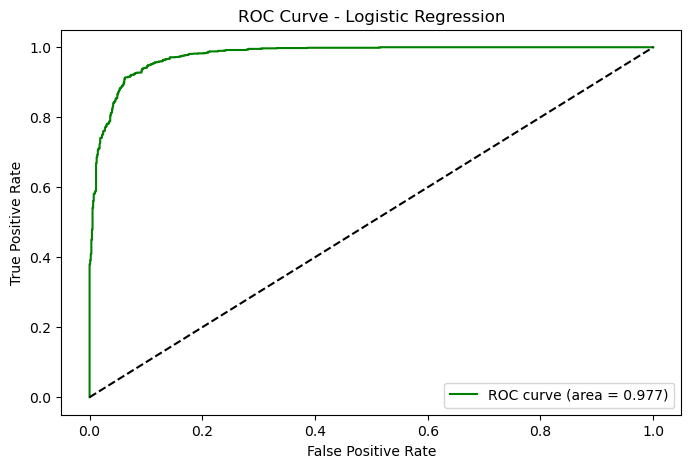

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.3f})', c = 'green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

The ROC curve visualizes the trade off between the True Positive Rate and the False Positive Rate. Our area under the curve is approximately 0.977, which is extremely high, telling us that the logistic rogression model does a really good job distinguishing between -1 and 1 for the 'Result' variable. In other words, we have a very low False Positive Rate and a very high True Positive Rate. The dashed line at the 45 degree angle represents the performance of a model that is simply guessing randomly; our model lies far above this line.

### 2) Produce a decision tree model to predict the Result column and using the 80-20 split comemnt on the tree diagram shown and the results (show the tree produced).

Now, we would like to run a different type of model, using the training and testing data we previously created.

In [46]:
tree = DecisionTreeClassifier(random_state = 42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Having created our model fit, we can test the accuracy of our model by making predictions of our 'Result' variable using the testing data, then comparing those predictions to the actual values of our 'Result' variable.

In [47]:
tree_pred = tree.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_pred)
print(f"Decision Tree Accuracy: {tree_accuracy:.4f}")

Decision Tree Accuracy: 0.9575


The accuracy we obtain from this regression is even higher than what we observed for the logistic regression model, at around 95.75%. Breaking this down into a confusion matrix as we did previously:

In [48]:
cm = confusion_matrix(y_test, tree_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 909   47]
 [  47 1208]]


Therefore, the model correctly 909 observations as -1s and 1,208 observations as 1s. However, 47 observations were incorrectly predicted as 1s when they were actually -1s, and 47 were incorrectly predicted as -1s when they should have been classified as 1s. We see better results in all categories, in comparison to logistic regression ( the number of True Positives and True Negatives increased, while the number of False Positives and False Negatives decreased). To plot the decision tree:

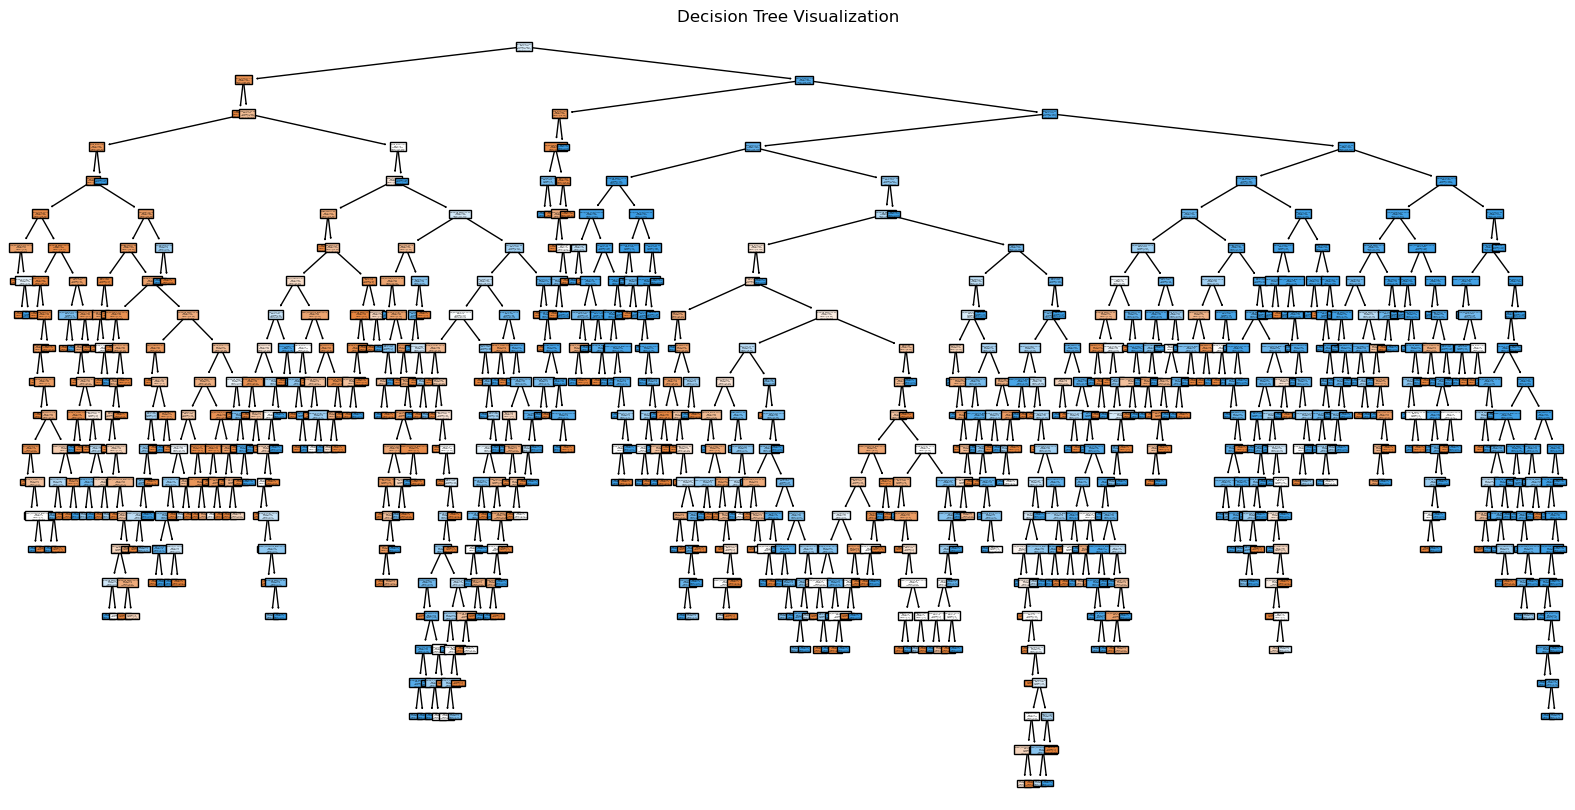

In [49]:
plt.figure(figsize = (20, 10))
plot_tree(tree, feature_names = X.columns, class_names = ['Legitimate', 'Phishing'], filled = True)
plt.title("Decision Tree Visualization")
plt.show()

Each node represents a decision, specifying the feature and theshold used for splitting, as well as the class distribution. Unfortunately, this decision tree is incredibly complex and difficult to interpret. While not too surprising because we used all thirty predictor variables to train our model, it is harder to offer any insight because there are so many levels of splits. However, we might count how many splits there are.

In [50]:
structure = tree.tree_
num_splits = sum(structure.children_left != -1)
print(f"Number of Splits in Tree: {num_splits}")

Number of Splits in Tree: 481


This tree has 481 splits, further indicating that it is extremely complex and uses many different features/decision rules to predict.

### 3) From both models reduce the number of variables you think is ok which simplifies the model but keeps a similar accuracy on the testing. Comment on the results of how many variables are needed for each model and the overlap.

In order to determine which variables are most relevant for both the logistic regression model and the decision tree model, we should look at both the coefficients of the logistic model and the feature importance from the tree model because this will show us which variables have the greatest impact. Starting with logistic:

In [51]:
log_coef = np.abs(log.coef_[0])
log_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_coef
}).sort_values(by = 'Coefficient', ascending = False)

print(log_importance)

                        Feature  Coefficient
13                URL_of_Anchor     3.198605
5                 Prefix_Suffix     2.876547
7                SSLfinal_State     1.605136
18                     Redirect     1.123422
28       Links_pointing_to_page     0.887795
15                          SFH     0.857299
14                Links_in_tags     0.842173
25                  web_traffic     0.806270
2            Shortining_Service     0.740749
27                 Google_Index     0.679029
0             having_IP_Address     0.674131
6             having_Sub_Domain     0.614041
10                         port     0.568321
24                    DNSRecord     0.564970
11                  HTTPS_token     0.498294
16          Submitting_to_email     0.386983
29           Statistical_report     0.333725
9                       Favicon     0.309333
22                       Iframe     0.304126
19                 on_mouseover     0.298388
3              having_At_Symbol     0.275599
12        

From the absolute value of our coefficients, we see that the most prominent features in our logistic model were 'URL_of_Anchor' (which analyzes anchor tages and their trustworthiness), 'Prefix_Suffix' (which checks if the url has a hyphen, commonly used in phishing domains), 'SSLfinal_State' (an indicator of whether or not the website has a valid SSL certificate), and 'Redirect' (phishing sites may have an extreme amount of redirects, so this counts them). We see that of our thirty features, there are some definitely having less of an effect on our prediction than others. To keep a similar accuracy on the testing and simultaneously reduce the complexity of our model, we may have to go through trial and error to see how many variables should be used. I'll start with a threshold where the coefficient is above 0.5, which means using our top 14 variables, reducing the number of variables by a little over half.

In [52]:
top_log_importance = log_importance['Feature'].head(14).tolist()

We need to re-train a model with the smaller amount of features.

In [53]:
X_train_reduced = X_train[top_log_importance]
X_test_reduced = X_test[top_log_importance]

log_reduced = LogisticRegression(max_iter = 1000)
log_reduced.fit(X_train_reduced, y_train)

LogisticRegression(max_iter=1000)

In [54]:
y_pred_reduced = log_reduced.predict(X_test_reduced)

accuracy_reduced = accuracy_score(y_test, y_pred_reduced)
print(f"Reduced Logistic Regression Accuracy (Fourteen Features): {accuracy_reduced:.4f}")

Reduced Logistic Regression Accuracy (Fourteen Features): 0.9249


Interestingly, reducing the number of variables to fourteen actually increased our accuracy from 92.4% to 92.49%. This could be attributed to a few things. First, simpler models generalize better. By removing features that do not have as great of an impact on our 'Result' variable, the model not only becomes easier to interpret but also more robust. Second, if there are irrelevant or redundant features, they will simply increase complexity without adding much/any performance gain. Third, with too many variables, the model may overfit, performing well on the training data but less well on the testing data (even though our previous accuracy was very good).

Let's try again with our top ten variables.

In [55]:
top_log_importance = log_importance['Feature'].head(10).tolist()

X_train_reduced2 = X_train[top_log_importance]
X_test_reduced2 = X_test[top_log_importance]

log_reduced = LogisticRegression(max_iter = 1000)
log_reduced.fit(X_train_reduced2, y_train)

LogisticRegression(max_iter=1000)

In [56]:
y_pred_reduced2 = log_reduced.predict(X_test_reduced2)

accuracy_reduced = accuracy_score(y_test, y_pred_reduced2)
print(f"Reduced Logistic Regression Accuracy (Fourteen Features): {accuracy_reduced:.4f}")

Reduced Logistic Regression Accuracy (Fourteen Features): 0.9209


Here, we see that the model accuracy did decrease to 92.09%. This is still very good and very close, and it may be worth it to remove a few more variables for the sake of easier interpretation. Let's attempt this process one more time with just the top eight variables:

In [57]:
top_log_importance = log_importance['Feature'].head(8).tolist()

X_train_reduced3 = X_train[top_log_importance]
X_test_reduced3 = X_test[top_log_importance]

log_reduced = LogisticRegression(max_iter = 1000)
log_reduced.fit(X_train_reduced3, y_train)

LogisticRegression(max_iter=1000)

In [58]:
y_pred_reduced3 = log_reduced.predict(X_test_reduced3)

accuracy_reduced = accuracy_score(y_test, y_pred_reduced3)
print(f"Reduced Logistic Regression Accuracy (Fourteen Features): {accuracy_reduced:.4f}")

Reduced Logistic Regression Accuracy (Fourteen Features): 0.9199


Here our model accuracy has decreased slightly more by .1% to 91.99%. This is only a .41 decrease in accuracy from the initial model with all thirty of our features. To me, eight variables seems like a good option for balancing simplicity with accuracy. Let's observe what the coefficients of our variables are in this model.

In [59]:
log_coef = np.abs(log_reduced.coef_[0])
log_importance = pd.DataFrame({
    'Feature': top_log_importance,
    'Coefficient': log_coef
}).sort_values(by = 'Coefficient', ascending = False)

print(log_importance)

                  Feature  Coefficient
0           URL_of_Anchor     3.059205
1           Prefix_Suffix     2.913480
2          SSLfinal_State     1.678307
6           Links_in_tags     0.882362
5                     SFH     0.855070
7             web_traffic     0.718779
3                Redirect     0.552585
4  Links_pointing_to_page     0.342104


We can now comment on the differences between the impact of these variables here and the impact of these variables when we initially contained all thirty features. Previously, with all variables 'URL_of_Anchor', 'Prefix_Suffix', and 'SSLfinal_State' all led the way in terms of most impact with coefficients of 3.198605, 2.876547, and 1.605136, respectively. Now, their coefficients are equal to 3.059205, 2.91348, and 1.678307 (so the impact of 'URL_of_Anchor' decreased slightly, while the impact of the other two increased a tiny bit). 'Redirect' and 'Links_pointing_to_page' had the fourth and fifth greatest coefficients (1.123422 and 0.887795) when we utilized all variables, but they are now the two lowest coefficients of our eight variables (0.552585 and 0.342104). Our other three variables, 'Links_in_tags', 'SFH', and 'web_traffic', were each the next largest coefficients in our previous model. 'SFH' was sixth with a coefficient of 0.857299, 'Links_in_tags' was seventh with a coefficient of 0.842173, and 'web_traffic' was eight with a coefficient of 0.80627. Their impact in this reduced model has shifted their order somewhat, with 'Links_in_tags' having the fourth largest coefficient of 0.882362, 'SFH' the fifth largest of 0.85507, and 'web_traffic' the sixth largest of 0.718779.

Next, let's try reducing the number of variables in the decision tree model. With this, we are able to actually use feature importance.

In [60]:
tree_importances = tree.feature_importances_

tree_features = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_importances
}).sort_values(by = 'Importance', ascending = False)

print(tree_features)

                        Feature  Importance
7                SSLfinal_State    0.614113
13                URL_of_Anchor    0.111681
14                Links_in_tags    0.032957
25                  web_traffic    0.030191
6             having_Sub_Domain    0.029637
5                 Prefix_Suffix    0.025527
28       Links_pointing_to_page    0.019651
23                age_of_domain    0.016203
12                  Request_URL    0.016172
0             having_IP_Address    0.011720
27                 Google_Index    0.011623
26                    Page_Rank    0.009480
24                    DNSRecord    0.009339
15                          SFH    0.008045
8   Domain_registeration_length    0.007999
16          Submitting_to_email    0.006420
1                    URL_Length    0.006272
3              having_At_Symbol    0.005681
9                       Favicon    0.003836
21                  popUpWidnow    0.003464
19                 on_mouseover    0.003416
18                     Redirect 

Feature importance breaks down how much each feature contributes to reducing the uncertainty within a model's predictions (reducing impurity). These values are normalized, so they all sum to one, making it extremely easy to measure how relevant they are relative to each other. 

Again, let's start with trial and error, the threshold being that the feature importance is greater than .01. This reduces our model only eleven variables.

In [61]:
top_tree_features = tree_features['Feature'].head(11).tolist()

X_train_reduced_tree = X_train[top_tree_features]
X_test_reduced_tree = X_test[top_tree_features]

tree_reduced = DecisionTreeClassifier(random_state = 42)
tree_reduced.fit(X_train_reduced_tree, y_train)

DecisionTreeClassifier(random_state=42)

In [62]:
tree_pred_reduced = tree_reduced.predict(X_test_reduced_tree)
tree_accuracy_reduced = accuracy_score(y_test, tree_pred_reduced)
print(f"Decision Tree Accuracy: {tree_accuracy_reduced:.4f}")

Decision Tree Accuracy: 0.9521


Reducing the number of variables from thirty to eleven decreased our accuracy slightly by 0.52%, a slight drop from 95.75% to 95.21%. This isn't bad at all. Given that our previous tree was incredibly hard to interpret, it may not hurt to reduce the variables somewhat more. Let's increase our threshold to variables with an importance greater than 0.02 now, keeping only the top six features.

In [63]:
top_tree_features = tree_features['Feature'].head(6).tolist()

X_train_reduced_tree2 = X_train[top_tree_features]
X_test_reduced_tree2 = X_test[top_tree_features]

tree_reduced2 = DecisionTreeClassifier(random_state = 42)
tree_reduced2.fit(X_train_reduced_tree2, y_train)

DecisionTreeClassifier(random_state=42)

In [64]:
tree_pred_reduced2 = tree_reduced2.predict(X_test_reduced_tree2)
tree_accuracy_reduced = accuracy_score(y_test, tree_pred_reduced2)
print(f"Decision Tree Accuracy: {tree_accuracy_reduced:.4f}")

Decision Tree Accuracy: 0.9398


Here, the accuracy of our decision tree decreased more than before, this time by 1.77% (95.75% to 93.98%). Personally, I feel that this is too far from our initial accuracy, so some of these variables should be left in. Let's try our top eight (a number in between six and eleven) variables to see how this affects the model accuracy.

In [65]:
top_tree_features = tree_features['Feature'].head(8).tolist()

X_train_reduced_tree3 = X_train[top_tree_features]
X_test_reduced_tree3 = X_test[top_tree_features]

tree_reduced3 = DecisionTreeClassifier(random_state = 42)
tree_reduced3.fit(X_train_reduced_tree3, y_train)

DecisionTreeClassifier(random_state=42)

In [66]:
tree_pred_reduced3 = tree_reduced3.predict(X_test_reduced_tree3)
tree_accuracy_reduced = accuracy_score(y_test, tree_pred_reduced3)
print(f"Decision Tree Accuracy: {tree_accuracy_reduced:.4f}")

Decision Tree Accuracy: 0.9462


To me, this is a somewhat better result. Our accuracy decreased from 95.75% to 94.62%, a 1.13% decrease. Yet, considering we've eliminated twenty-two of our thirty features in the process, this seems like a reasonable drop. Now, we might compare the feature importance of these eight variables to their importance values previously.

In [67]:
tree_importances = tree_reduced3.feature_importances_

tree_features = pd.DataFrame({
    'Feature': top_tree_features,
    'Importance': tree_importances
}).sort_values(by = 'Importance', ascending = False)

print(tree_features)

                  Feature  Importance
0          SSLfinal_State    0.697470
1           URL_of_Anchor    0.129148
4       having_Sub_Domain    0.038776
2           Links_in_tags    0.037834
3             web_traffic    0.033458
5           Prefix_Suffix    0.029272
6  Links_pointing_to_page    0.026061
7           age_of_domain    0.007981


The change that has occured in our feature importance is as follows: 'SSLfinal_State' and 'URL_of_Anchor' initially had the greatest and second-greatest impact on our 'Result' column with importances of 0.614113 and 0.111681, respectively. Of these eight most important features in our reduced model, they both still have the most impact, with importances of 0.69747 and 0.129148. 

In our full model, the other six variables listed above still maintained the next greatest impacts, but their ordering of importance is different in the reduced model. Previously 'having_Sub_Domain' had an importance of 0.029637, while it now has an importance of 0.038776. 'Links_in_tags' had an importance of 0.032957, while now it is 0.037834. 'web_traffic' had an importance of 0.030191, and it is now 0.033458. 'Prefix_Suffix' had an importance of 0.025527, and it is 0.029272 in this reduced model. 'Links_pointing_to_page' had an importance of 0.019651, but its importance now is 0.026061. Finally, 'age_of_domain' had an importance of 0.016203 and its importance in the reduced model is 0.007981.

We see that our logistic regression model and our decision tree model contain some of the same variables.

In [68]:
overlap = set(top_log_importance).intersection(set(top_tree_features))
print(f"Number of overlapping features: {len(overlap)}")
print("Overlapping features:", overlap)

Number of overlapping features: 6
Overlapping features: {'Links_pointing_to_page', 'Prefix_Suffix', 'URL_of_Anchor', 'Links_in_tags', 'web_traffic', 'SSLfinal_State'}


Therefore, six of the eight variables in both models are the same. These features are 'Prefix_Suffix', 'Links_in_tags', "SSLfinal_State', 'Links_pointing_to_page', "URL_of_Anchor', and 'web_traffic'. 

### 4) Perform PCA on the data, showing the distribution of the eigen values.

Principal Component Analysis is a process that deals with dimension-reduction, not variable-reduction. Here, we will utilize all of our data and observe the eigenvector(s) that create the clearest distinctions amongst our data.

As in Question 1, our data needs to be scaled. Once this is accomplished, we may proceed to the PCA process.

In [69]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)
eigenvalues = pca.explained_variance_

As requested, let's observe the distribution of the eigenvalues:

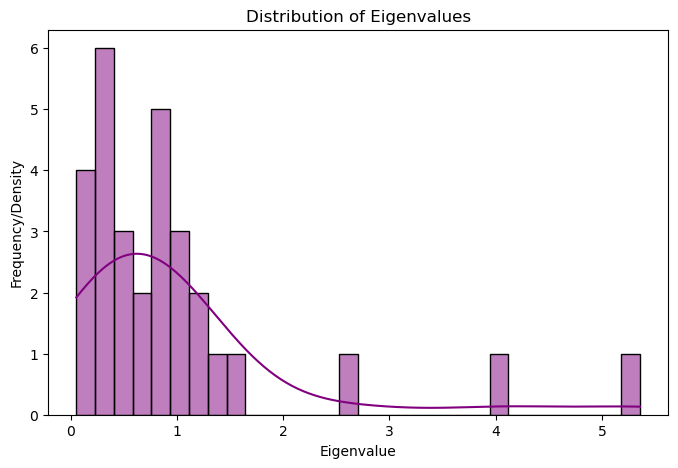

In [70]:
plt.figure(figsize = (8, 5))
sns.histplot(eigenvalues, bins = 30, kde = True, color = 'purple', edgecolor = 'black')
plt.title("Distribution of Eigenvalues")
plt.xlabel("Eigenvalue")
plt.ylabel("Frequency/Density")
plt.show()

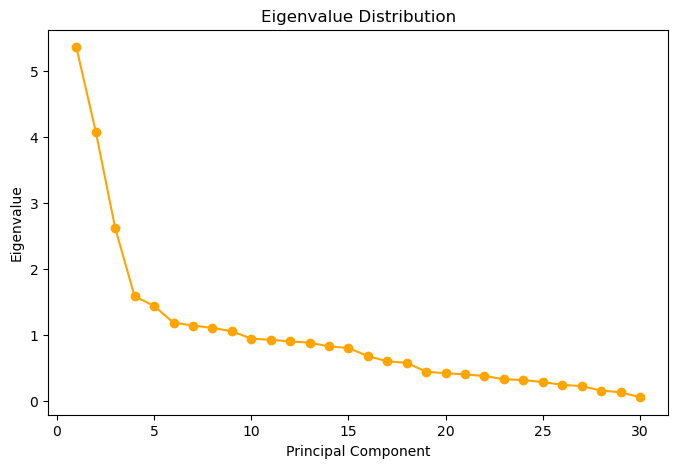

In [71]:
plt.figure(figsize = (8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker = 'o', color = 'orange')
plt.title("Eigenvalue Distribution")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.show()

From both plot, we clearly see our first three Principal Components explain the most in our variance; with the histogram, we see very noticeable gaps between eigenvalues before reaching the fourth eigenvalue, and the second plot shows us that their slopes are very steep. After hitting the fourth Principal Component, the histogram reveals that our eigenvalues are more clustered together so there is less of a drastic difference between the remaining eigenvalues. Our latter visual also demonstrates this, as after we pass the fourth Principal Component, the slope starts to level off; each eigenvalue still contributes to capturing the variance, but the amount it captures isn't as great proportionally. We can also calculate this mathematically.

In [72]:
print(eigenvalues)

[5.3583731  4.07917653 2.61490481 1.58257942 1.4368754  1.18245183
 1.13914624 1.10286464 1.05288374 0.94091791 0.92388901 0.89774877
 0.87986438 0.82285085 0.79883747 0.67554318 0.59661215 0.57370841
 0.43897042 0.41633431 0.39957012 0.37316497 0.32556362 0.31242437
 0.28250503 0.24025894 0.22108769 0.1539351  0.1271718  0.05249973]


In [73]:
variance = np.sum(eigenvalues)
print("Total Variance:", variance)

Total Variance: 30.002713949701462


Therefore, we see the total variance our eigenvalues capture is approximately equal to 30.

In [74]:
ratio = eigenvalues / variance
print("Cumulative Ratio:\n", ratio)

Cumulative Ratio:
 [0.17859628 0.13596025 0.08715561 0.05274788 0.04789151 0.0394115
 0.03796811 0.03675883 0.03509295 0.03136109 0.03079351 0.02992225
 0.02932616 0.02742588 0.02662551 0.02251607 0.01988527 0.01912188
 0.01463102 0.01387655 0.0133178  0.01243771 0.01085114 0.0104132
 0.00941598 0.00800791 0.00736892 0.00513071 0.00423868 0.00174983]


From this, we see that our first Principal Component explains approximately 18% of the variance in our data, while the second Principal Component accounts for almost 14%. The third Principal Component follows at close to 9%, but then from there the slope becomes less steep, with the following components explaining no more than 5.3% of the variance. The smallest eigenvalue does not even capture .1% of the variance.

### 5) Choose the two eigenvectors and project the data (except Result) onto those eigenvectors. Then plot the data where each point is colored according to the 'Result' value. Comment on the results.

In [75]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

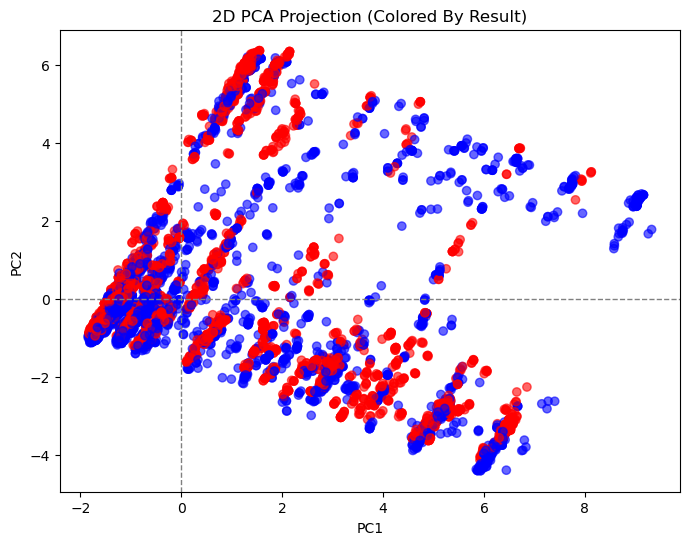

In [76]:
plt.figure(figsize = (8, 6))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c = y, cmap = 'bwr', alpha = 0.6)
plt.title("2D PCA Projection (Colored By Result)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.axhline(y = 0, color='gray', linestyle='--', linewidth=1)
plt.axvline(x = 0, color='gray', linestyle='--', linewidth=1)
plt.show()

This data is very interesting, as shape-wise it does not look very random. There are no data points toward the bottom left of the plot where PC2 is extremely negative and PC1 is somewhat negative, nor are there any where PC2 is extremely positive and PC1 is somewhat negative. However, there appears to be a good amount of data clustered to the left of (0,0), where PC1 ranges from -2 to 0 and PC2 ranges from -2 to 2.

Additionally, there are not any data points toward the top and bottom right of the plot, where PC1 is extremely positive and PC2 is either extremely positive or extremely negative. The data appears to follow a structure similar to a box, where all the data points are contained within the box and each side has an almost constant slope (as though it is linear).

Moreover, there does not appear to be a clear pattern regarding the 'Result' column; whether a data point corresponds to a 1 or -1 in that regard doesn't have much to do with where it appears on the plot.

### Using just two eigenvectors what accuracy from the projections can be produced for the Result column values as a target?

To obtain an accuracy, we need to generate a new model, training on just the dimension-reduced features. Again, recall that we are still using all the information.

In [77]:
X_train_pca2, X_test_pca2, y_train, y_test = train_test_split(
    X_pca2, y, test_size = 0.2, random_state = 42)

log_pca2 = LogisticRegression(max_iter = 1000)
log_pca2.fit(X_train_pca2, y_train)

LogisticRegression(max_iter=1000)

In [78]:
y_pred_pca2 = log_pca2.predict(X_test_pca2)

accuracy_pca2 = accuracy_score(y_test, y_pred_pca2)
print(f"Accuracy with Two PCA Components: {accuracy_pca2:.4f}")

Accuracy with Two PCA Components: 0.5527


The accuracy of this model with two principal components is not good at all, at around 55.27%. Given the plot we generated above, this is not too surprising, as there really was no clear way to determine where along the plot a result of 1 would end up compared to a result of -1.

### 7) Using more than two eigenvectors, what is a reasonable accuracy that can be obtained?

We had thirty features and thus thirty eigenvectors. It was very clear that not all of the eigenvectors had a strong impact on explaining the variance in our data, so it would be good to try a various number of eigenvectors, maybe three eigenvectors up to fifteen.

In [79]:
accuracies = []
c_range = range(3, 16)

for n in c_range:
    pca = PCA(n_components = n)
    X_pca = pca.fit_transform(X_scaled)
    X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
        X_pca, y, test_size = 0.2, random_state = 42
    )
    model = LogisticRegression(max_iter = 1000)
    model.fit(X_train_pca, y_train_pca)
    accuracy = accuracy_score(y_test_pca, model.predict(X_test_pca))
    accuracies.append(accuracy)
    print(f"Accuracy with {n} PCA Components: {accuracy:.4f}")
    

Accuracy with 3 PCA Components: 0.8485
Accuracy with 4 PCA Components: 0.9168
Accuracy with 5 PCA Components: 0.9168
Accuracy with 6 PCA Components: 0.9168
Accuracy with 7 PCA Components: 0.9177
Accuracy with 8 PCA Components: 0.9154
Accuracy with 9 PCA Components: 0.9163
Accuracy with 10 PCA Components: 0.9190
Accuracy with 11 PCA Components: 0.9227
Accuracy with 12 PCA Components: 0.9218
Accuracy with 13 PCA Components: 0.9213
Accuracy with 14 PCA Components: 0.9195
Accuracy with 15 PCA Components: 0.9213


Observing this, we see that there was a drastic jump as soon as we moved from two eigenvectors to three (from 55.27% to 84.85%). This is significant and confirms what we had seen in the earlier plot of the distribution of eigenvalues, as the slope of the third Principal Component was still pretty significant. 

Additionally, while not as great of a jump, we see a significant increase going from the third component to the fourth (84.85% to 91.68%), further validating what was shown in the distribution plot.

Adding more components after the fourth does not do much to increase our accuracy; it bounces around, ranging from about 91% to 93%, so there is no major difference in accuracy after the fourth component. As stated before, the goal of Principal Component Analysis is to reduce the dimensionality of our data while preserving as much of the original information as we can, making it easier to analyze. Therefore, since there is not that significant of a change in the accuracy after the fourth component, I think sticking with just four eigenvectors/components yields the best results. We obtain an accuracy of about 91.41% and have reduced the number of dimensions in our dataset by twenty-six.

### 7) Using two eigenvectors project the data (excluding Result column) onto a pair of numbers for each row, then append the Result column value (in total 3 numbers produced). Save this 3 column data as a csv. Do the same process but using more eigenvectors, not all of them though, saving the data to another csv.

In [80]:
pca2_df = pd.DataFrame(X_pca2, columns = ['PC1', 'PC2'])
pca2_df['Result'] = y
pca2_df.to_csv("pca2_assignment4.csv", index = False)

This gives us a csv file in our working directory with the projected data of just two components, and adds the 'Result' column to it. Now, let's repeat this process with the four eigenvectors.

In [81]:
pca4 = PCA(n_components = 4)
X_pca4 = pca4.fit_transform(X_scaled)
pca4_df = pd.DataFrame(X_pca4, columns = ['PC1', 'PC2', 'PC3', 'PC4'])
pca4_df['Result'] = y
pca4_df.to_csv("pca4_assignment4.csv", index = False)

### 9) Load the previously made csv files and apply logistic regression and decision trees to each using an 80-20 split for training and testing. Report on the accuracy and compare to the accuracy from the original data.

Let's begin with the two component data.

In [82]:
phish2 = pd.read_csv("pca2_assignment4.csv")

To split our data into training and testing, we need to differentiate between the dependent and independent variables.

In [83]:
X2 = phish2.drop('Result', axis = 1)
y2 = phish2['Result']

In [84]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size = 0.2, random_state = 42)

Having split our data, we may now perform logistic regression and obtain the accuracy from it.

In [85]:
log2 = LogisticRegression(max_iter = 1000)
log2.fit(X_train2, y_train2)

LogisticRegression(max_iter=1000)

In [86]:
y_pred2 = log2.predict(X_test2)

accuracy2 = accuracy_score(y_test2, y_pred2)
print(f"Accuracy with Two PCA Components (Logistic): {accuracy2:.4f}")

Accuracy with Two PCA Components (Logistic): 0.5527


Unsurprisingly, since we completed this same process in part 6 to get an idea of the accuracy we could obtain from just these two largest eigenvectors, we get the same results. Using two PCA components does not explain as much of the variation in our data that we need to make accurate predictions.

However, we did not try this process in part 6 using a decision tree model, so let's test that out now.

In [87]:
tree2 = DecisionTreeClassifier(random_state = 42)
tree2.fit(X_train2, y_train2)

DecisionTreeClassifier(random_state=42)

In [88]:
tree_pred2 = tree2.predict(X_test2)

accuracy2 = accuracy_score(y_test2, tree_pred2)
print(f"Accuracy with Two PCA Components (DT): {accuracy2:.4f}")

Accuracy with Two PCA Components (DT): 0.8557


So using a decision tree model actually drastically improves our accuracy when just using the primary two Principal Components, yielding a result of about 85.57%. This isn't too surprising since decision trees tend to perform better than logistic regression models. 

Comparing these results to the original data, we see that reducing the dimensionality does not do well with logistic regression. Using all thirty features and all dimensions gave us an accuracy of 92.4%, while this dimension-reduced model using only the top two Principal Components gave us an accuracy of only 55.27%.

Alternatively, decision tree classification handled this process significantly better. While reducing the dimensions decreased our accuracy to 85.57%, this is not as far of a jump from the 95.75% accuracy we obtained initially using all thirty features and dimensions. 

Next, let's repeat this process with the four component data.

In [89]:
phish4 = pd.read_csv("pca4_assignment4.csv")

In [90]:
X4 = phish4.drop('Result', axis = 1)
y4 = phish4['Result']

In [91]:
X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X4, y4, test_size = 0.2, random_state = 42)

First, let's perform logistic regression:

In [92]:
log4 = LogisticRegression(max_iter = 1000)
log4.fit(X_train4, y_train4)

LogisticRegression(max_iter=1000)

In [93]:
y_pred4 = log4.predict(X_test4)

accuracy4 = accuracy_score(y_test4, y_pred4)
print(f"Accuracy with Four PCA Components (Logistic): {accuracy4:.4f}")

Accuracy with Four PCA Components (Logistic): 0.9154


And from above, we see a significant improvement in the accuracy (approximately 91.54%) compared to when we just used two Principal Components. With the original data, we had obtained an accuracy of 92.4%, so reducing our dimensions from thirty to four does not drastically decrease our accuracy.

Repeating this with decision trees:

In [94]:
tree4 = DecisionTreeClassifier(random_state = 42)
tree4.fit(X_train4, y_train4)

DecisionTreeClassifier(random_state=42)

In [95]:
tree_pred4 = tree4.predict(X_test4)

accuracy4 = accuracy_score(y_test4, tree_pred4)
print(f"Accuracy with Four PCA Components (DT): {accuracy4:.4f}")

Accuracy with Four PCA Components (DT): 0.9421


Similarly, we see an improvement in our accuracy when going from two PCA components to four. Compared to our original data, this accuracy is also not too far off. When we utilzied all thirty features/dimensions, the accuracy was 95.75%; here, our accuracy is 94.21%, only slightly above a 1% decrease.

In conclusion, dimension-reduction can allow us to achieve very similar results to those yieled when we don't apply dimension-reduction. Ultimately, it can come down to the model we are using and the number of dimensions we reduce to. For example, there was a prominent difference between the reduced logistic model and the full logistic model when using two components, but this difference did not appear as great when applying decision trees. Furthermore, when increasing from just two components to four, both reduced models performed very similarly to the full models. Even a relatively small increase from two to four Principal Components had a major impact on our models' accuracies.